# NC Capstone: A.I. Business Sentiment and Employment by State
This notebook loads and combines BLS and BTOS datasets using relative paths, then seeks to analyze the relationship between A.I. sentiment and employment by type and U.S. State over time. 

---

Load Libraries

In [3]:
import pandas as pd
from glob import glob
import os

Checking to Make Sure File Path is Working

In [4]:
bls_paths = sorted(glob("data/state_M20*_dl.xlsx"))
print("Files found:")
print(bls_paths)

Files found:
['data\\state_M2020_dl.xlsx', 'data\\state_M2021_dl.xlsx', 'data\\state_M2022_dl.xlsx', 'data\\state_M2023_dl.xlsx', 'data\\state_M2024_dl.xlsx']


Load and Combine BLS Data
This block loads all BLS Excel files from the `data/` folder.

In [5]:

bls_dfs = []

for path in bls_paths:
    try:
        df = pd.read_excel(path)
        df["source_file"] = os.path.basename(path)
        bls_dfs.append(df)
    except Exception as e:
        print(f"Failed to load {path}: {e}")

# Combine all BLS data
bls_combined = pd.concat(bls_dfs, ignore_index=True)
print("\n BLS data combined. Sample:")
display(bls_combined.head())


 BLS data combined. Sample:


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,source_file,PCT_RPT
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,41.07,18690,24060,36250,56980,85430,NaN,NaN,state_M2020_dl.xlsx,NaN
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,91.89,47740,67330,95120,134320,191130,NaN,NaN,state_M2020_dl.xlsx,NaN
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,#,49480,97930,161290,#,#,NaN,NaN,state_M2020_dl.xlsx,NaN
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,#,48030,67740,101170,153050,#,NaN,NaN,state_M2020_dl.xlsx,NaN
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,*,16220,17190,18820,27920,55970,True,NaN,state_M2020_dl.xlsx,NaN


Adding 'Tech' Classification to BLS Occupational Data

In [6]:
# Add tech classification column to BLS data
print("Adding tech classification to BLS data")

# Create the tech flag based on OCC_TITLE containing "Data" or "Software"
bls_combined['Tech_Classification'] = bls_combined['OCC_TITLE'].apply(
    lambda x: 'Tech' if pd.notna(x) and ('DATA' in str(x).upper() or 'SOFTWARE' in str(x).upper()) 
    else 'Non Tech'
)

# Verify the classification
tech_counts = bls_combined['Tech_Classification'].value_counts()
print(f"\nTech Classification Counts:")
print(tech_counts)

# Show some examples of Tech-classified jobs
print(f"\nSample Tech-classified occupations:")
tech_jobs = bls_combined[bls_combined['Tech_Classification'] == 'Tech']['OCC_TITLE'].unique()
print(tech_jobs[:10])  # Show first 10 unique tech job titles

print(f"\nBLS data updated with Tech_Classification column.")
print(f"New shape: {bls_combined.shape}")

Adding tech classification to BLS data

Tech Classification Counts:
Tech_Classification
Non Tech    184322
Tech          1432
Name: count, dtype: int64

Sample Tech-classified occupations:
['Database Administrators and Architects'
 'Software Developers and Software Quality Assurance Analysts and Testers'
 'Data Scientists and Mathematical Science Occupations, All Other'
 'Data Entry Keyers' 'Database Administrators' 'Database Architects'
 'Software Developers' 'Software Quality Assurance Analysts and Testers'
 'Data Scientists']

BLS data updated with Tech_Classification column.
New shape: (185754, 34)


BTOS Collection Date Translation Added Here

In [7]:
date_translation_path = "data/btos_collection_dates.csv"
try:
    date_translation = pd.read_csv(date_translation_path)
    print("BTOS date translation loaded successfully.")
    display(date_translation.head())
except Exception as e:
    print(f"Failed to load {date_translation_path}: {e}")

BTOS date translation loaded successfully.


,Smpdt,Col Start,Col End,Ref Start,Ref End
0,202215,07/18/2022,07/31/2022,07/04/2022,07/17/2022
1,202216,08/01/2022,08/14/2022,07/18/2022,07/31/2022
2,202217,08/15/2022,08/28/2022,08/01/2022,08/14/2022
3,202218,08/29/2022,09/11/2022,08/15/2022,08/28/2022
4,202219,09/12/2022,09/25/2022,08/29/2022,09/11/2022


Load and Combine BTOS Data.  
This block loads the BTOS survey data files from the `data/` folder.

In [8]:
btos_paths = ["data/State.xlsx", "data/State_v1.xlsx"]
btos_dfs = []

for path in btos_paths:
    try:
        df = pd.read_excel(path)
        df["source_file"] = os.path.basename(path)
        btos_dfs.append(df)
    except Exception as e:
        print(f"Failed to load {path}: {e}")

# Combine all BTOS data
btos_combined = pd.concat(btos_dfs, ignore_index=True)
print("\n BTOS data combined. Sample:")
display(btos_combined.head())


 BTOS data combined. Sample:


,State,Question ID,Question,Answer ID,Answer,202512,202511,202510,202509,202508,...,202224,202223,202222,202221,202220,202219,202218,202217,202216,202215
0,AK,2.0,"Overall, how would you describe this business'...",1.0,Excellent,S,S,S,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AK,2.0,"Overall, how would you describe this business'...",2.0,Above average,17.9%,16.5%,13.9%,19.6%,21.4%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AK,2.0,"Overall, how would you describe this business'...",3.0,Average,46.2%,52.9%,69.6%,34.6%,57.1%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AK,2.0,"Overall, how would you describe this business'...",4.0,Below average,18.2%,18.2%,S,32.1%,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AK,2.0,"Overall, how would you describe this business'...",5.0,Poor,S,S,S,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Renaming BTOS Date Columns to Make them More Usable

In [9]:

collection_dates = pd.read_csv(date_translation_path)
print("BTOS collection dates loaded successfully.")
display(collection_dates.head())

# Convert Smpdt to string and create mapping
collection_dates['Smpdt'] = collection_dates['Smpdt'].astype(str)
date_mapping = dict(zip(collection_dates['Smpdt'], collection_dates['Ref End']))

# Check current BTOS columns
print("Current BTOS date columns:", [col for col in btos_combined.columns if str(col).startswith('202')][:10])

# Find matching columns and rename
date_columns = [col for col in btos_combined.columns if str(col) in date_mapping.keys()]
print(f"Found {len(date_columns)} matching columns to rename")

if len(date_columns) > 0:
    rename_dict = {col: date_mapping[str(col)] for col in date_columns}
    btos_combined = btos_combined.rename(columns=rename_dict)
    print(f"Successfully renamed {len(rename_dict)} date columns to Ref End dates.")
    
    # Verify the renaming worked
    print("Sample new column names:", list(btos_combined.columns)[-10:])
else:
    print("No matching columns found")

BTOS collection dates loaded successfully.


,Smpdt,Col Start,Col End,Ref Start,Ref End
0,202215,07/18/2022,07/31/2022,07/04/2022,07/17/2022
1,202216,08/01/2022,08/14/2022,07/18/2022,07/31/2022
2,202217,08/15/2022,08/28/2022,08/01/2022,08/14/2022
3,202218,08/29/2022,09/11/2022,08/15/2022,08/28/2022
4,202219,09/12/2022,09/25/2022,08/29/2022,09/11/2022


Current BTOS date columns: ['202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503']
Found 76 matching columns to rename
Successfully renamed 76 date columns to Ref End dates.
Sample new column names: ['11/20/2022', '11/06/2022', '10/23/2022', '10/09/2022', '09/25/2022', '09/11/2022', '08/28/2022', '08/14/2022', '07/31/2022', '07/17/2022']


Adding 'Region' Column to Both Files

In [10]:
region_mapping = {
    # Northeast
    'ME': 'Northeast', 'NH': 'Northeast', 'VT': 'Northeast', 'MA': 'Northeast', 
    'RI': 'Northeast', 'CT': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast', 
    'NJ': 'Northeast', 'DE': 'Northeast', 'MD': 'Northeast',
    
    # Southeast
    'FL': 'Southeast', 'AL': 'Southeast', 'GA': 'Southeast', 'SC': 'Southeast', 
    'NC': 'Southeast', 'VA': 'Southeast', 'WV': 'Southeast', 'KY': 'Southeast', 
    'TN': 'Southeast', 'MS': 'Southeast', 'AR': 'Southeast', 'LA': 'Southeast',
    
    # Midwest
    'OH': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'IL': 'Midwest', 
    'WI': 'Midwest', 'MN': 'Midwest', 'IA': 'Midwest', 'MO': 'Midwest', 
    'ND': 'Midwest', 'SD': 'Midwest', 'NE': 'Midwest', 'KS': 'Midwest',
    
    # Southwest
    'TX': 'Southwest', 'NM': 'Southwest', 'AZ': 'Southwest', 'OK': 'Southwest',
    
    # West
    'CA': 'West', 'OR': 'West', 'WA': 'West', 'NV': 'West', 'ID': 'West', 
    'MT': 'West', 'WY': 'West', 'UT': 'West', 'CO': 'West', 'AK': 'West', 'HI': 'West',

    # Territories
    'DC': 'Territories', 'GU': 'Territories', 'PR': 'Territories', 'VI': 'Territories',
    'XX': 'Territories'
}

# Add Region column to BLS data
print("Adding regional classification to BLS data...")
bls_combined['Region'] = bls_combined['PRIM_STATE'].map(region_mapping)

# Add Region column to BTOS data  
print("Adding regional classification to BTOS data...")
btos_combined['Region'] = btos_combined['State'].map(region_mapping)

# Verify the regional classifications
print(f"\nBLS Regional Distribution:")
print(bls_combined['Region'].value_counts())

print(f"\nBTOS Regional Distribution:")
print(btos_combined['Region'].value_counts())

# Check for any unmapped states
bls_unmapped = bls_combined[bls_combined['Region'].isna()]['PRIM_STATE'].unique()
btos_unmapped = btos_combined[btos_combined['Region'].isna()]['State'].unique()

if len(bls_unmapped) > 0:
    print(f"\nUnmapped BLS states: {bls_unmapped}")
if len(btos_unmapped) > 0:
    print(f"\nUnmapped BTOS states: {btos_unmapped}")

print(f"\nRegional classification complete!")
print(f"BLS data shape: {bls_combined.shape}")
print(f"BTOS data shape: {btos_combined.shape}")

Adding regional classification to BLS data...
Adding regional classification to BTOS data...

BLS Regional Distribution:
Region
Southeast      44633
Midwest        43745
Northeast      37951
West           36975
Southwest      14799
Territories     7651
Name: count, dtype: int64

BTOS Regional Distribution:
Region
Southeast      2160
Midwest        2160
West           1980
Northeast      1980
Southwest       720
Territories     455
Name: count, dtype: int64

Unmapped BTOS states: [nan
 'Source: U.S. Census Bureau, Business Trends and Outlook Survey (BTOS). The Census Bureau has reviewed this data product to ensure appropriate access, use, and disclosure avoidance protection of the confidential source data.\n        (Project No. P-7529868, Disclosure Review Board (DRB) approval number: CBDRB-FY24-0474)'
 'Source: U.S. Census Bureau, Business Trends and Outlook Survey (BTOS), Posted date: September 14, 2023, Project No. EID-7529868 / Approval CBDRB-FY22-341.']

Regional classification co

Creating a Year Column for BLS Data

In [11]:
# Extract year from BLS source_file column
print("Extracting year from BLS source files...")

# Extract 4-digit year from filenames like "state_M2020_dl.xlsx"
bls_combined['Year'] = bls_combined['source_file'].str.extract(r'(\d{4})')

# Convert to integer for easier analysis
bls_combined['Year'] = bls_combined['Year'].astype(int)

# Verify the year extraction
print(f"\nYear extraction verification:")
year_counts = bls_combined['Year'].value_counts().sort_index()
print(year_counts)

# Show sample of source files and extracted years
print(f"\nSample source files and extracted years:")
sample_check = bls_combined[['source_file', 'Year']].drop_duplicates().sort_values('Year')
print(sample_check)

print(f"\nYear column successfully added to BLS data!")
print(f"Years covered: {bls_combined['Year'].min()} - {bls_combined['Year'].max()}")

Extracting year from BLS source files...



Year extraction verification:
Year
2020    36085
2021    37580
2022    37569
2023    37676
2024    36844
Name: count, dtype: int64

Sample source files and extracted years:
                source_file  Year
0       state_M2020_dl.xlsx  2020
36085   state_M2021_dl.xlsx  2021
73665   state_M2022_dl.xlsx  2022
111234  state_M2023_dl.xlsx  2023
148910  state_M2024_dl.xlsx  2024

Year column successfully added to BLS data!
Years covered: 2020 - 2024


Save Combined Outputs

In [12]:
bls_combined.to_csv("data/combined_bls.csv", index=False)
btos_combined.to_csv("data/combined_btos.csv", index=False)
print("\n Output saved: data/combined_bls.csv and data/combined_btos.csv")


 Output saved: data/combined_bls.csv and data/combined_btos.csv


Combined Staging Data Preview

In [13]:
print("\nPreview: BLS Combined Data")
display(bls_combined.head())

print("\nPreview: BTOS Combined Data")
display(btos_combined.head())


Preview: BLS Combined Data


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,source_file,PCT_RPT,Tech_Classification,Region,Year
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,36250,56980,85430,NaN,NaN,state_M2020_dl.xlsx,NaN,Non Tech,Southeast,2020
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,95120,134320,191130,NaN,NaN,state_M2020_dl.xlsx,NaN,Non Tech,Southeast,2020
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,161290,#,#,NaN,NaN,state_M2020_dl.xlsx,NaN,Non Tech,Southeast,2020
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,101170,153050,#,NaN,NaN,state_M2020_dl.xlsx,NaN,Non Tech,Southeast,2020
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,18820,27920,55970,True,NaN,state_M2020_dl.xlsx,NaN,Non Tech,Southeast,2020



Preview: BTOS Combined Data


,State,Question ID,Question,Answer ID,Answer,06/01/2025,05/18/2025,05/04/2025,04/20/2025,04/06/2025,...,11/06/2022,10/23/2022,10/09/2022,09/25/2022,09/11/2022,08/28/2022,08/14/2022,07/31/2022,07/17/2022,Region
0,AK,2.0,"Overall, how would you describe this business'...",1.0,Excellent,S,S,S,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West
1,AK,2.0,"Overall, how would you describe this business'...",2.0,Above average,17.9%,16.5%,13.9%,19.6%,21.4%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West
2,AK,2.0,"Overall, how would you describe this business'...",3.0,Average,46.2%,52.9%,69.6%,34.6%,57.1%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West
3,AK,2.0,"Overall, how would you describe this business'...",4.0,Below average,18.2%,18.2%,S,32.1%,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West
4,AK,2.0,"Overall, how would you describe this business'...",5.0,Poor,S,S,S,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West


Selecting the Relevant A.I. Questions from the BTOS Survey

In [14]:
from pandasql import sqldf

btos_combined.columns = btos_combined.columns.str.replace(' ', '_')
btos_combined = btos_combined.loc[:, ~btos_combined.columns.isna()]

# I am only using the "State" source - which goes as far back as Sept 2023, 
# (cont'd) because prior to Sept 2023 (State v1 file) there was not an A.I. question in the data.

query = """
SELECT distinct Question, Question_ID
FROM btos_combined
WHERE 1=1
and Question like '%Artificial Intelligence%'
and source_file in ('State.xlsx')
limit 10
"""
print("\nQuerying BTOS Combined Data for AI-related questions:")


result = sqldf(query, locals())


print(result)


Querying BTOS Combined Data for AI-related questions:
                                            Question  Question_ID
0  In the last two weeks, did this business use A...          7.0
1  During the next six months, do you think this ...         26.0


Getting Cleaned BTOS Dataset Together

In [15]:
# Filter BTOS data to only AI-related questions
print("Filtering BTOS data to AI-related questions only")

# Filter for only the two AI questions we identified
ai_questions_filter = (btos_combined['Question_ID'].isin([7.0, 26.0])) & \
                     (btos_combined['source_file'] == 'State.xlsx')

btos_ai_only = btos_combined[ai_questions_filter].copy()

print(f"Original BTOS data shape: {btos_combined.shape}")
print(f"Filtered AI-only data shape: {btos_ai_only.shape}")
print(f"Reduction: {btos_combined.shape[0] - btos_ai_only.shape[0]:,} rows removed")

# Verify the filtering worked
print("\nUnique questions remaining:")
verification_query = """
SELECT DISTINCT Question_ID, Question, COUNT(*) as row_count
FROM btos_ai_only
GROUP BY Question_ID, Question
"""
verification_result = sqldf(verification_query, locals())
print(verification_result)

# Update the main dataframe reference
btos_combined = btos_ai_only
print("\nBTOS dataset successfully reduced to AI-related questions only.")

Filtering BTOS data to AI-related questions only
Original BTOS data shape: (9459, 83)
Filtered AI-only data shape: (318, 83)
Reduction: 9,141 rows removed

Unique questions remaining:
   Question_ID                                           Question  row_count
0          7.0  In the last two weeks, did this business use A...        159
1         26.0  During the next six months, do you think this ...        159

BTOS dataset successfully reduced to AI-related questions only.


Custom Functions - 1, getting current and perceived near term A.I. adoption rates

In [16]:
import pandas as pd
from typing import List

def get_btos_yes_rates(df: pd.DataFrame, date_columns: List[str]) -> pd.DataFrame:

    results = []
    
    # Get unique states and questions
    states = df['State'].unique()
    questions = df['Question_ID'].unique()
    
    for state in states:
        if pd.isna(state):
            continue
            
        # Get region for this state
        state_data = df[df['State'] == state]
        region = state_data['Region'].iloc[0] if not state_data.empty and 'Region' in state_data.columns else None
            
        for question_id in questions:
            if pd.isna(question_id):
                continue
                
            # Get question text for clarity
            question_text = df[df['Question_ID'] == question_id]['Question'].iloc[0] if len(df[df['Question_ID'] == question_id]) > 0 else f"Question {question_id}"
            
            for date_col in date_columns:
                if date_col not in df.columns:
                    continue
                
                # Filter for this state and question
                state_question_data = df[
                    (df['State'] == state) & 
                    (df['Question_ID'] == question_id)
                ]
                
                if state_question_data.empty:
                    continue
                
                # Get the 'Yes' response for this date
                yes_data = state_question_data[state_question_data['Answer'] == 'Yes']
                
                if not yes_data.empty and date_col in yes_data.columns:
                    yes_value = yes_data[date_col].iloc[0]
                    
                    # Convert percentage to number
                    if pd.notna(yes_value) and yes_value != 'S':
                        try:
                            if isinstance(yes_value, str) and '%' in yes_value:
                                yes_rate = float(yes_value.replace('%', ''))
                            else:
                                yes_rate = float(yes_value)
                                
                            results.append({
                                'State': state,
                                'Region': region,
                                'Question_ID': question_id,
                                'Question_Type': 'Current_Usage' if question_id == 7.0 else 'Future_Plans',
                                'Date': date_col,
                                'Yes_Rate': yes_rate,
                                'Question_Text': question_text[:50] + '...'  # Truncated for readability
                            })
                        except (ValueError, TypeError):
                            continue
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Sort for better readability
    if not results_df.empty:
        results_df = results_df.sort_values(['State', 'Question_ID', 'Date'])
    
    return results_df

Region Usage

In [17]:
# Get AI Yes rates with regions
target_dates = ['12/29/2024', '12/31/2023']
yes_rates_df = get_btos_yes_rates(btos_combined, target_dates)

# Regional analysis
regional_summary = yes_rates_df.groupby(['Region', 'Question_Type', 'Date'])['Yes_Rate'].mean().round(2)
print("Average AI Yes Rates by Region:")
print(regional_summary)

Average AI Yes Rates by Region:
Region       Question_Type  Date      
Midwest      Current_Usage  12/29/2024     5.51
                            12/31/2023     3.77
             Future_Plans   12/29/2024     8.76
                            12/31/2023     5.54
Northeast    Current_Usage  12/29/2024     5.42
                            12/31/2023     4.18
             Future_Plans   12/29/2024     9.11
                            12/31/2023     6.53
Southeast    Current_Usage  12/29/2024     5.67
                            12/31/2023     4.40
             Future_Plans   12/29/2024     8.74
                            12/31/2023     5.66
Southwest    Current_Usage  12/29/2024     6.03
                            12/31/2023     4.95
             Future_Plans   12/29/2024     7.32
                            12/31/2023     5.70
Territories  Current_Usage  12/29/2024     8.70
                            12/31/2023     5.15
             Future_Plans   12/29/2024    11.30
                 

State Usage

In [18]:
# Just current AI usage (Question 7)
current_usage = yes_rates_df[yes_rates_df['Question_ID'] == 7.0]
print("Current AI Usage Yes Rates:")
print(current_usage[['State', 'Date', 'Yes_Rate']])

# Just future AI plans (Question 26)  
future_plans = yes_rates_df[yes_rates_df['Question_ID'] == 26.0]
print("Future AI Plans Yes Rates:")
print(future_plans[['State', 'Date', 'Yes_Rate']])

Current AI Usage Yes Rates:
    State        Date  Yes_Rate
0      AL  12/29/2024       3.5
1      AL  12/31/2023       3.3
4      AR  12/29/2024       5.8
6      AZ  12/29/2024       6.1
7      AZ  12/31/2023       5.3
..    ...         ...       ...
141    WA  12/31/2023       5.9
144    WI  12/29/2024       4.8
145    WI  12/31/2023       2.7
148    XX  12/29/2024       8.7
149    XX  12/31/2023       5.0

[70 rows x 3 columns]
Future AI Plans Yes Rates:
    State        Date  Yes_Rate
2      AL  12/29/2024       6.5
3      AL  12/31/2023       4.8
5      AR  12/29/2024       9.0
8      AZ  12/29/2024       7.9
9      AZ  12/31/2023       7.3
..    ...         ...       ...
143    WA  12/31/2023       7.4
146    WI  12/29/2024       8.9
147    WI  12/31/2023       5.1
150    XX  12/29/2024      13.8
151    XX  12/31/2023       9.4

[82 rows x 3 columns]


Customer Function 2 - Tech Employment Movement by State During the Same Period

In [19]:
import pandas as pd
from typing import List

def get_tech_employment_summary(df: pd.DataFrame, years: List[int]) -> pd.DataFrame:

    # Filter for specified years
    filtered_df = df[df['Year'].isin(years)].copy()
    
    # Clean TOT_EMP column - convert to numeric, handle special characters
    filtered_df['TOT_EMP_Clean'] = pd.to_numeric(filtered_df['TOT_EMP'], errors='coerce')
    
    # Group by State, Region, Year, Tech_Classification and sum TOT_EMP
    summary = filtered_df.groupby(['PRIM_STATE', 'Region', 'Year', 'Tech_Classification'])['TOT_EMP_Clean'].sum().reset_index()
    
    # Pivot to get Tech and Non Tech as separate columns
    pivot_summary = summary.pivot_table(
        index=['PRIM_STATE', 'Region', 'Year'], 
        columns='Tech_Classification', 
        values='TOT_EMP_Clean', 
        fill_value=0
    ).reset_index()
    
    # Flatten column names
    pivot_summary.columns.name = None
    
    # Calculate totals and percentages
    pivot_summary['Total_Employment'] = pivot_summary['Non Tech'] + pivot_summary['Tech']
    pivot_summary['Tech_Percentage'] = round((pivot_summary['Tech'] / pivot_summary['Total_Employment'] * 100), 2)
    
    # Rename columns for clarity
    pivot_summary = pivot_summary.rename(columns={
        'PRIM_STATE': 'State',
        'Non Tech': 'Non_Tech_Employment',
        'Tech': 'Tech_Employment'
    })
    
    # Convert employment numbers to integers for cleaner display
    pivot_summary['Tech_Employment'] = pivot_summary['Tech_Employment'].astype(int)
    pivot_summary['Non_Tech_Employment'] = pivot_summary['Non_Tech_Employment'].astype(int)
    pivot_summary['Total_Employment'] = pivot_summary['Total_Employment'].astype(int)
    
    # Sort by region and state
    pivot_summary = pivot_summary.sort_values(['Region', 'State', 'Year'])
    
    return pivot_summary

Tech Employment by State / Region

In [20]:
# Get tech employment using actual TOT_EMP numbers
tech_summary = get_tech_employment_summary(bls_combined, [2023, 2024])
print(tech_summary.head())

   State   Region  Year  Non_Tech_Employment  Tech_Employment  \
25    IA  Midwest  2023              4615900            15180   
26    IA  Midwest  2024              4664480            14820   
29    IL  Midwest  2023             17903740            82960   
30    IL  Midwest  2024             18042890            79110   
31    IN  Midwest  2023              9443590            22700   

    Total_Employment  Tech_Percentage  
25           4631080             0.33  
26           4679300             0.32  
29          17986700             0.46  
30          18122000             0.44  
31           9466290             0.24  


Custom Function 3 - Uniting BLS and BOTS Data by State and Region

In [21]:
import pandas as pd
from typing import List

def unite_tech_and_ai_data(bls_df: pd.DataFrame, btos_df: pd.DataFrame, 
                          years: List[int], dates: List[str]) -> pd.DataFrame:

    # Get tech employment data (keeps separate rows for each year)
    tech_data = get_tech_employment_summary(bls_df, years)
    
    # Get AI adoption data
    ai_data = get_btos_yes_rates(btos_df, dates)
    
    # Map dates to years for merging
    date_to_year = {}
    for date in dates:
        year = int(date.split('/')[-1])  # Extract year from MM/DD/YYYY format
        date_to_year[date] = year
    
    # Add year column to AI data based on the 'Date' column from BTOS function
    ai_data['Year'] = ai_data['Date'].map(date_to_year)
    
    # Average AI data by State, Region, Year, and Question_Type (in case multiple dates per year)
    ai_avg = ai_data.groupby(['State', 'Region', 'Year', 'Question_Type']).agg({
        'Yes_Rate': 'mean'
    }).round(2).reset_index()
    
    # Pivot AI data to get Current_Usage and Future_Plans as separate columns
    ai_pivot = ai_avg.pivot_table(
        index=['State', 'Region', 'Year'], 
        columns='Question_Type', 
        values='Yes_Rate', 
        fill_value=0
    ).reset_index()
    
    # Flatten column names
    ai_pivot.columns.name = None
    
    # Rename AI columns for clarity
    if 'Current_Usage' in ai_pivot.columns:
        ai_pivot = ai_pivot.rename(columns={'Current_Usage': 'AI_Current_Usage'})
    if 'Future_Plans' in ai_pivot.columns:
        ai_pivot = ai_pivot.rename(columns={'Future_Plans': 'AI_Future_Plans'})
    
    # Merge tech and AI data on State, Region, and Year
    combined_data = pd.merge(tech_data, ai_pivot, on=['State', 'Region', 'Year'], how='left')
    
    # Add some calculated fields for easier plotting
    combined_data['Tech_Employment_Thousands'] = round(combined_data['Tech_Employment'] / 1000, 1)
    combined_data['Total_Employment_Millions'] = round(combined_data['Total_Employment'] / 1000000, 2)
    
    # Fill any missing AI data with 0 (states that might not have AI survey data)
    combined_data['AI_Current_Usage'] = combined_data['AI_Current_Usage'].fillna(0)
    combined_data['AI_Future_Plans'] = combined_data['AI_Future_Plans'].fillna(0)
    
    # Sort by region, state, and year for better readability
    combined_data = combined_data.sort_values(['Region', 'State', 'Year'])
    
    return combined_data

Results in a Table

In [22]:
plot_data = unite_tech_and_ai_data(
    bls_combined, 
    btos_combined, 
    [2023, 2024], 
    ['12/31/2023', '12/29/2024']
)

print("Combined dataset created!")
print(f"Shape: {plot_data.shape}")
print("\nFirst 10 rows:")
print(plot_data.head(10))

# Check Alabama 2023 specifically
al_2023 = plot_data[(plot_data['State'] == 'AL') & (plot_data['Year'] == 2023)]
print(f"\nAlabama 2023:")
print(al_2023[['State', 'Year', 'AI_Current_Usage', 'AI_Future_Plans']])

Combined dataset created!
Shape: (107, 11)

First 10 rows:
  State   Region  Year  Non_Tech_Employment  Tech_Employment  \
0    IA  Midwest  2023              4615900            15180   
1    IA  Midwest  2024              4664480            14820   
2    IL  Midwest  2023             17903740            82960   
3    IL  Midwest  2024             18042890            79110   
4    IN  Midwest  2023              9443590            22700   
5    IN  Midwest  2024              9528380            21980   
6    KS  Midwest  2023              4204800            18300   
7    KS  Midwest  2024              4268670            19310   
8    MI  Midwest  2023             12977000            57940   
9    MI  Midwest  2024             13103260            56760   

   Total_Employment  Tech_Percentage  AI_Current_Usage  AI_Future_Plans  \
0           4631080             0.33               2.8              4.8   
1           4679300             0.32               7.5              8.5   
2          

Alabama Test

In [23]:
# Get all Alabama data (both years)
al_data = plot_data[plot_data['State'] == 'AL']
print("Alabama - Complete Data:")
print(al_data)

# Show Alabama trends
print(f"\nAlabama Trends (2023 → 2024):")
print(f"Tech Employment: {al_data[al_data['Year']==2023]['Tech_Employment'].iloc[0]:,} → {al_data[al_data['Year']==2024]['Tech_Employment'].iloc[0]:,}")
print(f"Tech Percentage: {al_data[al_data['Year']==2023]['Tech_Percentage'].iloc[0]}% → {al_data[al_data['Year']==2024]['Tech_Percentage'].iloc[0]}%")
print(f"AI Current Usage: {al_data[al_data['Year']==2023]['AI_Current_Usage'].iloc[0]}% → {al_data[al_data['Year']==2024]['AI_Current_Usage'].iloc[0]}%")
print(f"AI Future Plans: {al_data[al_data['Year']==2023]['AI_Future_Plans'].iloc[0]}% → {al_data[al_data['Year']==2024]['AI_Future_Plans'].iloc[0]}%")

Alabama - Complete Data:
   State     Region  Year  Non_Tech_Employment  Tech_Employment  \
46    AL  Southeast  2023              6113920            23030   
47    AL  Southeast  2024              6216930            24960   

    Total_Employment  Tech_Percentage  AI_Current_Usage  AI_Future_Plans  \
46           6136950             0.38               3.3              4.8   
47           6241890             0.40               3.5              6.5   

    Tech_Employment_Thousands  Total_Employment_Millions  
46                       23.0                       6.14  
47                       25.0                       6.24  

Alabama Trends (2023 → 2024):
Tech Employment: 23,030 → 24,960
Tech Percentage: 0.38% → 0.4%
AI Current Usage: 3.3% → 3.5%
AI Future Plans: 4.8% → 6.5%


SQL Lite DB Build

In [24]:
import sqlite3
import pandas as pd
from typing import Optional

def create_capstone_database(bls_df: pd.DataFrame, btos_df: pd.DataFrame, 
                           combined_df: pd.DataFrame, db_path: str = "data/capstone_analysis.db") -> None:
    """
    Create SQLite database with properly structured tables for capstone analysis.
    
    Args:
        bls_df (pd.DataFrame): Cleaned BLS employment data
        btos_df (pd.DataFrame): Cleaned BTOS AI sentiment data  
        combined_df (pd.DataFrame): Combined analysis dataset
        db_path (str): Path for the SQLite database file
    """
    # Create database connection
    conn = sqlite3.connect(db_path)
    
    try:
        # Table 1: Employment Data (from BLS)
        # Primary key: state_code + year (composite key)
        employment_data = bls_df.groupby(['PRIM_STATE', 'Region', 'Year', 'Tech_Classification']).agg({
            'TOT_EMP': lambda x: pd.to_numeric(x, errors='coerce').sum()
        }).reset_index()
        
        # Pivot to get tech vs non-tech employment
        employment_pivot = employment_data.pivot_table(
            index=['PRIM_STATE', 'Region', 'Year'],
            columns='Tech_Classification', 
            values='TOT_EMP',
            fill_value=0
        ).reset_index()
        
        employment_pivot.columns.name = None
        employment_pivot = employment_pivot.rename(columns={
            'PRIM_STATE': 'state_code',
            'Region': 'region',
            'Year': 'year',
            'Non Tech': 'non_tech_employment',
            'Tech': 'tech_employment'
        })
        
        # Add calculated fields
        employment_pivot['total_employment'] = employment_pivot['non_tech_employment'] + employment_pivot['tech_employment']
        employment_pivot['tech_percentage'] = (employment_pivot['tech_employment'] / employment_pivot['total_employment'] * 100).round(2)
        
        # Create primary key
        employment_pivot['employment_id'] = employment_pivot['state_code'] + '_' + employment_pivot['year'].astype(str)
        
        # Save to SQLite
        employment_pivot.to_sql('employment_data', conn, if_exists='replace', index=False)
        print(f"Employment data table created: {len(employment_pivot)} records")
        
        # Table 2: AI Sentiment Data (from BTOS)
        # Primary key: state_code + year + question_type
        ai_sentiment_data = []
        
        # Process AI data by state, year, and question type
        for _, row in combined_df.iterrows():
            if row['AI_Current_Usage'] > 0:  # Only include states with AI data
                ai_sentiment_data.append({
                    'state_code': row['State'],
                    'region': row['Region'],
                    'year': row['Year'],
                    'question_type': 'current_usage',
                    'yes_rate': row['AI_Current_Usage'] / 100.0,  # Convert to decimal format
                    'question_text': 'In the last two weeks, did this business use AI?'
                })
                
            if row['AI_Future_Plans'] > 0:
                ai_sentiment_data.append({
                    'state_code': row['State'],
                    'region': row['Region'], 
                    'year': row['Year'],
                    'question_type': 'future_plans',
                    'yes_rate': row['AI_Future_Plans'] / 100.0,  # Convert to decimal format
                    'question_text': 'During the next six months, will this business use AI?'
                })
        
        ai_df = pd.DataFrame(ai_sentiment_data)
        
        if not ai_df.empty:
            # Create primary key
            ai_df['sentiment_id'] = ai_df['state_code'] + '_' + ai_df['year'].astype(str) + '_' + ai_df['question_type']
            
            # Save to SQLite
            ai_df.to_sql('ai_sentiment_data', conn, if_exists='replace', index=False)
            print(f"AI sentiment data table created: {len(ai_df)} records")
        
        # Table 3: Regional Reference Data (for joins)
        regional_data = bls_df[['PRIM_STATE', 'Region']].drop_duplicates().rename(columns={
            'PRIM_STATE': 'state_code',
            'Region': 'region'
        })
        regional_data['region_id'] = regional_data['region'].str.lower().str.replace(' ', '_')
        
        regional_data.to_sql('regional_reference', conn, if_exists='replace', index=False)
        print(f"Regional reference table created: {len(regional_data)} records")
        
        # Create indexes for better performance
        cursor = conn.cursor()
        cursor.execute("CREATE INDEX IF NOT EXISTS idx_employment_state_year ON employment_data(state_code, year)")
        cursor.execute("CREATE INDEX IF NOT EXISTS idx_sentiment_state_year ON ai_sentiment_data(state_code, year)")
        cursor.execute("CREATE INDEX IF NOT EXISTS idx_regional_state ON regional_reference(state_code)")
        
        print(f"\nDatabase created successfully: {db_path}")
        
    except Exception as e:
        print(f"Error creating database: {e}")
        
    finally:
        conn.close()


def query_visualization_data(db_path: str = "data/capstone_analysis.db", 
                           analysis_type: str = "correlation") -> pd.DataFrame:
    """
    Perform SQL joins to retrieve data for specific visualizations.
    
    Args:
        db_path (str): Path to the SQLite database
        analysis_type (str): Type of analysis ('correlation', 'regional', 'trends')
        
    Returns:
        pd.DataFrame: Joined data ready for visualization
    """
    conn = sqlite3.connect(db_path)
    
    try:
        if analysis_type == "correlation":
            # Join employment and AI sentiment data for correlation analysis
            query = """
            SELECT 
                e.state_code,
                e.region,
                e.year,
                e.tech_employment,
                e.total_employment,
                e.tech_percentage,
                current.yes_rate as current_ai_usage,
                future.yes_rate as future_ai_plans
            FROM employment_data e
            LEFT JOIN ai_sentiment_data current 
                ON e.state_code = current.state_code 
                AND e.year = current.year 
                AND current.question_type = 'current_usage'
            LEFT JOIN ai_sentiment_data future
                ON e.state_code = future.state_code 
                AND e.year = future.year 
                AND future.question_type = 'future_plans'
            WHERE e.year IN (2023, 2024)
            ORDER BY e.region, e.state_code, e.year
            """
            
        elif analysis_type == "regional":
            # Regional summary for geographic analysis
            query = """
            SELECT 
                e.region,
                e.year,
                SUM(e.tech_employment) as total_tech_jobs,
                AVG(current.yes_rate) as avg_current_ai_usage,
                AVG(future.yes_rate) as avg_future_ai_plans,
                COUNT(DISTINCT e.state_code) as state_count
            FROM employment_data e
            LEFT JOIN ai_sentiment_data current 
                ON e.state_code = current.state_code 
                AND e.year = current.year 
                AND current.question_type = 'current_usage'
            LEFT JOIN ai_sentiment_data future
                ON e.state_code = future.state_code 
                AND e.year = future.year 
                AND future.question_type = 'future_plans'
            WHERE e.year IN (2023, 2024)
            GROUP BY e.region, e.year
            ORDER BY e.region, e.year
            """
            
        elif analysis_type == "trends":
            # Year-over-year trends analysis
            query = """
            SELECT 
                states.state_code,
                states.region,
                e2023.tech_percentage / 100.0 as tech_2023,
                e2024.tech_percentage / 100.0 as tech_2024,
                (e2024.tech_percentage - e2023.tech_percentage) / 100.0 as tech_change,
                ai2023.yes_rate as ai_2023,
                ai2024.yes_rate as ai_2024,
                (ai2024.yes_rate - ai2023.yes_rate) as ai_change
            FROM (SELECT DISTINCT state_code, region FROM employment_data) states
            LEFT JOIN employment_data e2023 ON states.state_code = e2023.state_code AND e2023.year = 2023
            LEFT JOIN employment_data e2024 ON states.state_code = e2024.state_code AND e2024.year = 2024
            LEFT JOIN ai_sentiment_data ai2023 ON states.state_code = ai2023.state_code 
                AND ai2023.year = 2023 AND ai2023.question_type = 'current_usage'
            LEFT JOIN ai_sentiment_data ai2024 ON states.state_code = ai2024.state_code 
                AND ai2024.year = 2024 AND ai2024.question_type = 'current_usage'
            WHERE e2023.tech_percentage IS NOT NULL AND e2024.tech_percentage IS NOT NULL
            ORDER BY ai_change DESC
            """
        
        result_df = pd.read_sql_query(query, conn)
        print(f"Query executed: {len(result_df)} records returned for {analysis_type} analysis")
        return result_df
        
    except Exception as e:
        print(f"Error querying database: {e}")
        return pd.DataFrame()
        
    finally:
        conn.close()


def show_database_schema(db_path: str = "data/capstone_analysis.db") -> None:
    """
    Display the database schema and table information.
    
    Args:
        db_path (str): Path to the SQLite database
    """
    conn = sqlite3.connect(db_path)
    
    try:
        cursor = conn.cursor()
        
        # Get all tables
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()
        
        print("Database Schema:")
        print("=" * 50)
        
        for table in tables:
            table_name = table[0]
            print(f"\nTable: {table_name}")
            
            # Get table info
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            
            for col in columns:
                col_name, col_type, not_null, default, pk = col[1], col[2], col[3], col[4], col[5]
                pk_indicator = " (PRIMARY KEY)" if pk else ""
                print(f"   {col_name}: {col_type}{pk_indicator}")
            
            # Get row count
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            count = cursor.fetchone()[0]
            print(f"   Records: {count:,}")
    
    except Exception as e:
        print(f"Error reading schema: {e}")
        
    finally:
        conn.close()

Storing Data

In [25]:
# Create the SQLite database with properly structured tables
create_capstone_database(bls_combined, btos_combined, plot_data)

# Display database schema
show_database_schema()

# Recreate database to apply decimal formatting updates
print("\nRecreating database with updated decimal formatting...")
create_capstone_database(bls_combined, btos_combined, plot_data)

Employment data table created: 269 records
AI sentiment data table created: 146 records
Regional reference table created: 54 records

Database created successfully: data/capstone_analysis.db
Database Schema:

Table: employment_data
   state_code: TEXT
   region: TEXT
   year: INTEGER
   non_tech_employment: REAL
   tech_employment: REAL
   total_employment: REAL
   tech_percentage: REAL
   employment_id: TEXT
   Records: 269

Table: ai_sentiment_data
   state_code: TEXT
   region: TEXT
   year: INTEGER
   question_type: TEXT
   yes_rate: REAL
   question_text: TEXT
   sentiment_id: TEXT
   Records: 146

Table: regional_reference
   state_code: TEXT
   region: TEXT
   region_id: TEXT
   Records: 54

Recreating database with updated decimal formatting...
Employment data table created: 269 records
AI sentiment data table created: 146 records
Regional reference table created: 54 records

Database created successfully: data/capstone_analysis.db


Joins

In [26]:
# Example 1: Correlation Analysis Data (joins employment + AI sentiment)
correlation_data = query_visualization_data(analysis_type="correlation")
print("Correlation Analysis Dataset:")
print(correlation_data.head())

# Example 2: Regional Summary Data  
regional_data = query_visualization_data(analysis_type="regional")
print("\nRegional Analysis Dataset:")
print(regional_data.head())

# Example 3: Trends Analysis Data
trends_data = query_visualization_data(analysis_type="trends")
print("\nTrends Analysis Dataset:")
print(trends_data.head())

Query executed: 107 records returned for correlation analysis
Correlation Analysis Dataset:
  state_code   region  year  tech_employment  total_employment  \
0         IA  Midwest  2023          15180.0         4631080.0   
1         IA  Midwest  2024          14820.0         4679300.0   
2         IL  Midwest  2023          82960.0        17986700.0   
3         IL  Midwest  2024          79110.0        18122000.0   
4         IN  Midwest  2023          22700.0         9466290.0   

   tech_percentage  current_ai_usage  future_ai_plans  
0             0.33             0.028            0.048  
1             0.32             0.075            0.085  
2             0.46             0.044            0.063  
3             0.44             0.065            0.118  
4             0.24             0.031            0.052  
Query executed: 12 records returned for regional analysis

Regional Analysis Dataset:
      region  year  total_tech_jobs  avg_current_ai_usage  \
0    Midwest  2023         3

Visuals v2

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from typing import Optional

# Set up unified color theme and styling
def setup_plot_theme():
    """
    Configure a professional, unified color theme for all visualizations.
    """
    # Custom color palette - professional blues and teals
    colors = {
        'primary': '#2E86AB',      # Deep blue
        'secondary': '#A23B72',    # Burgundy 
        'accent': '#F18F01',       # Orange
        'light': '#C4E3F3',       # Light blue
        'dark': '#1B4D72',        # Dark blue
        'neutral': '#6C757D'       # Gray
    }
    
    # Set matplotlib style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Configure default parameters
    plt.rcParams.update({
        'figure.figsize': (12, 8),
        'axes.titlesize': 16,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 11,
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3
    })
    
    return colors

def create_scatter_plot(db_path: str = "data/capstone_analysis.db") -> None:
    """
    Create a scatter plot showing the relationship between tech employment 
    change (2023-2024) and current AI adoption rates by region.
    """
    colors = setup_plot_theme()
    
    # Get regional data from database (same source as bar chart)
    regional_data = query_visualization_data(db_path, "regional")
    correlation_data = query_visualization_data(db_path, "correlation")
    
    # Calculate tech employment change by region using actual employment numbers
    regional_changes = []
    for region in regional_data['region'].unique():
        # Get employment data for this region
        region_employment = regional_data[regional_data['region'] == region]
        
        # Get 2023 and 2024 employment totals
        employment_2023 = region_employment[region_employment['year'] == 2023]['total_tech_jobs']
        employment_2024 = region_employment[region_employment['year'] == 2024]['total_tech_jobs']
        
        if len(employment_2023) > 0 and len(employment_2024) > 0:
            emp_2023 = employment_2023.iloc[0]
            emp_2024 = employment_2024.iloc[0]
            
            # Calculate percentage change
            if emp_2023 > 0:  # Avoid division by zero
                percent_change = ((emp_2024 - emp_2023) / emp_2023) * 100
            else:
                percent_change = 0
            
            # Get 2024 AI adoption for this region
            region_ai_data = correlation_data[
                (correlation_data['region'] == region) & 
                (correlation_data['year'] == 2024) &
                (correlation_data['current_ai_usage'].notna()) &
                (correlation_data['current_ai_usage'] > 0)
            ]
            
            if len(region_ai_data) > 0:
                avg_ai_usage = region_ai_data['current_ai_usage'].mean() * 100  # Convert to percentage
                
                regional_changes.append({
                    'region': region,
                    'tech_employment_change': percent_change,
                    'ai_adoption_rate': avg_ai_usage,
                    'emp_2023': emp_2023,
                    'emp_2024': emp_2024
                })
    
    change_df = pd.DataFrame(regional_changes)
    
    # Debug print to verify calculations
    print("Employment Change Calculations:")
    print("=" * 40)
    for _, row in change_df.iterrows():
        print(f"{row['region']:>10}: {row['emp_2023']:>8,.0f} → {row['emp_2024']:>8,.0f} "
              f"({row['tech_employment_change']:>+6.2f}%)")
    print()
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create scatter plot with different colors by region
    region_colors = [colors['primary'], colors['secondary'], colors['accent'], 
                    colors['dark'], colors['light'], colors['neutral']]
    
    for i, region in enumerate(change_df['region']):
        region_row = change_df[change_df['region'] == region]
        ax.scatter(region_row['tech_employment_change'], 
                  region_row['ai_adoption_rate'],
                  c=region_colors[i % len(region_colors)], 
                  label=region, 
                  alpha=0.8, 
                  s=200,  # Larger points since we have fewer data points
                  edgecolors='white',
                  linewidth=2)
        
        # Add region labels next to points
        ax.annotate(region, 
                   (region_row['tech_employment_change'].iloc[0], 
                    region_row['ai_adoption_rate'].iloc[0]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold')
    
    # Add trend line if we have enough points
    if len(change_df) > 2:
        x = change_df['tech_employment_change']
        y = change_df['ai_adoption_rate']
        
        # Only calculate correlation if we have valid data
        if len(x) > 1 and x.std() > 0 and y.std() > 0:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), color=colors['neutral'], linestyle='--', alpha=0.8, linewidth=2)
            
            # Add correlation coefficient
            correlation_coef = np.corrcoef(x, y)[0, 1]
            ax.text(0.25, 0.85, f'Correlation: r = {correlation_coef:.3f}', 
                    transform=ax.transAxes, fontsize=12, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Customize the plot
    ax.set_xlabel('Tech Employment Change 2023-2024 (%)', fontweight='bold')
    ax.set_ylabel('Current AI Adoption Rate 2024 (%)', fontweight='bold')
    ax.set_title('Regional Tech Employment Growth vs AI Adoption (2024)', 
                fontsize=18, fontweight='bold', pad=20)
    
    # Add zero lines for reference
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    
    # Set grid
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    
    # Add subtle background color
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.show()

def create_bar_chart(db_path: str = "data/capstone_analysis.db") -> None:
    """
    Create a grouped bar chart comparing total tech jobs by region 
    between 2023 and 2024.
    """
    colors = setup_plot_theme()
    
    # Get regional data from database
    regional_data = query_visualization_data(db_path, "regional")
    
    # Pivot data for easier plotting
    pivot_data = regional_data.pivot(index='region', columns='year', values='total_tech_jobs')
    
    # Create the bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set bar positions
    x = np.arange(len(pivot_data.index))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, pivot_data[2023], width, 
                   label='2023', color=colors['primary'], alpha=0.8,
                   edgecolor='white', linewidth=1)
    bars2 = ax.bar(x + width/2, pivot_data[2024], width,
                   label='2024', color=colors['secondary'], alpha=0.8,
                   edgecolor='white', linewidth=1)
    
    # Add value labels on bars
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:,.0f}', ha='center', va='bottom', fontsize=9)
    
    add_value_labels(bars1, pivot_data[2023])
    add_value_labels(bars2, pivot_data[2024])
    
    # Customize the plot
    ax.set_xlabel('Region', fontweight='bold')
    ax.set_ylabel('Total Tech Employment (Jobs)', fontweight='bold')
    ax.set_title('Total Tech Employment by Region: 2023 vs 2024', 
                fontsize=18, fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right')
    
    # Format y-axis to show values in thousands
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    # Add legend
    ax.legend(title='Year', title_fontsize=12, fontsize=11, 
             loc='upper left', frameon=True, fancybox=True, shadow=True)
    
    # Customize grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Add subtle background color
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.show()

def create_heatmap_plot(db_path: str = "data/capstone_analysis.db") -> None:
    """
    Create a heatmap showing AI adoption rates (current vs future) by region and year.
    """
    colors = setup_plot_theme()
    
    # Get regional data from database
    regional_data = query_visualization_data(db_path, "regional")
    
    # Create separate heatmaps for current and future AI adoption
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Prepare data for current AI usage
    current_pivot = regional_data.pivot(index='region', columns='year', values='avg_current_ai_usage')
    current_pivot = current_pivot * 100  # Convert to percentage
    
    # Prepare data for future AI plans
    future_pivot = regional_data.pivot(index='region', columns='year', values='avg_future_ai_plans')
    future_pivot = future_pivot * 100  # Convert to percentage
    
    # Create custom colormap
    cmap = sns.color_palette("Blues", as_cmap=True)
    
    # Plot current AI usage heatmap
    sns.heatmap(current_pivot, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                cbar_kws={'label': 'AI Adoption Rate (%)'},
                ax=ax1,
                linewidths=0.5,
                linecolor='white')
    
    ax1.set_title('Current AI Usage by Region', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontweight='bold')
    ax1.set_ylabel('Region', fontweight='bold')
    
    # Plot future AI plans heatmap
    sns.heatmap(future_pivot, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                cbar_kws={'label': 'AI Adoption Rate (%)'},
                ax=ax2,
                linewidths=0.5,
                linecolor='white')
    
    ax2.set_title('Future AI Plans by Region', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontweight='bold')
    ax2.set_ylabel('Region', fontweight='bold')
    
    # Adjust layout
    plt.suptitle('AI Adoption Heatmap: Current Usage vs Future Plans', 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



def create_all_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """
    Create all three visualizations for the capstone analysis.
    
    Args:
        db_path (str): Path to the SQLite database
    """
    print("Creating Capstone Visualizations...")
    print("=" * 50)
    
    print("\n1. Scatter Plot: Tech Employment Change vs AI Adoption by Region")
    create_scatter_plot(db_path)
    
    print("\n2. Bar Chart: Total Tech Employment by Region")
    create_bar_chart(db_path)
    
    print("\n3. Heatmap: AI Adoption Patterns by Region and Time")
    create_heatmap_plot(db_path)
    


Creating Capstone Visualizations...

1. Scatter Plot: Tech Employment Change vs AI Adoption by Region
Query executed: 12 records returned for regional analysis
Query executed: 107 records returned for correlation analysis
Employment Change Calculations:
   Midwest:  389,440 →  387,910 ( -0.39%)
 Northeast:  472,930 →  489,140 ( +3.43%)
 Southeast:  502,750 →  500,190 ( -0.51%)
 Southwest:  290,100 →  296,870 ( +2.33%)
      West:  670,240 →  599,640 (-10.53%)



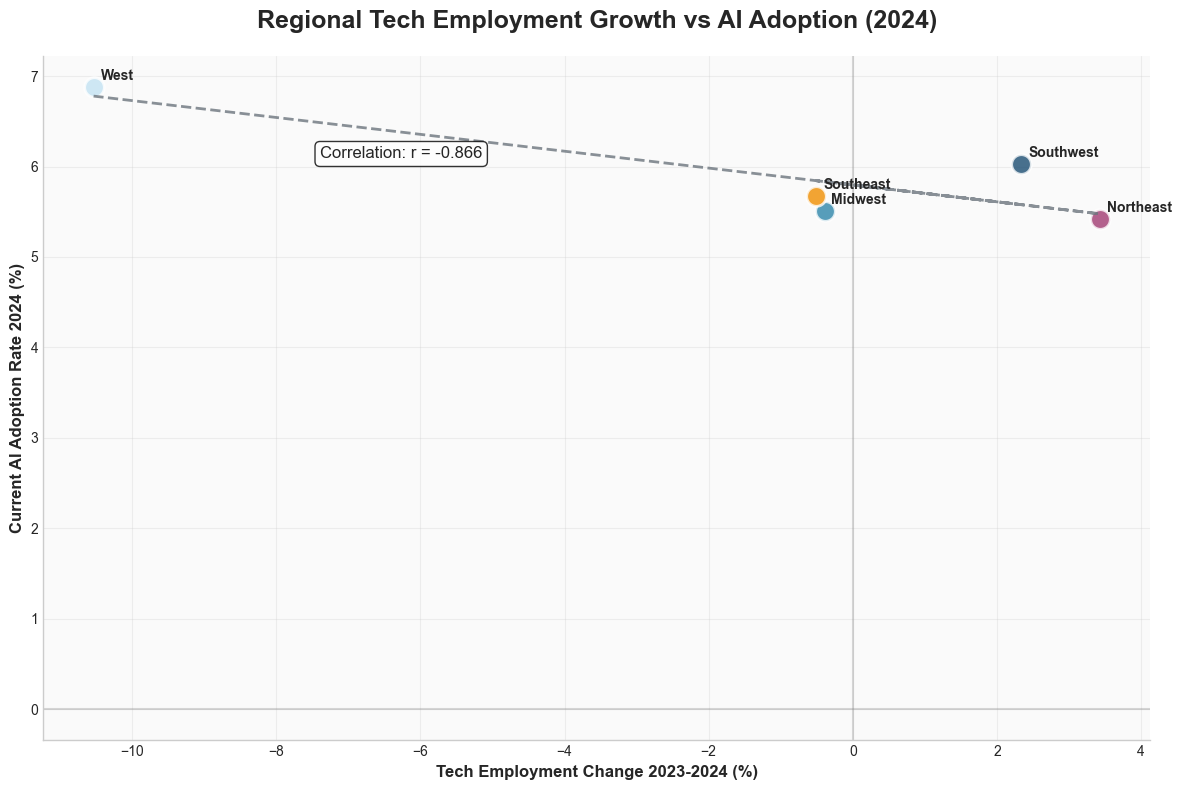


2. Bar Chart: Total Tech Employment by Region
Query executed: 12 records returned for regional analysis


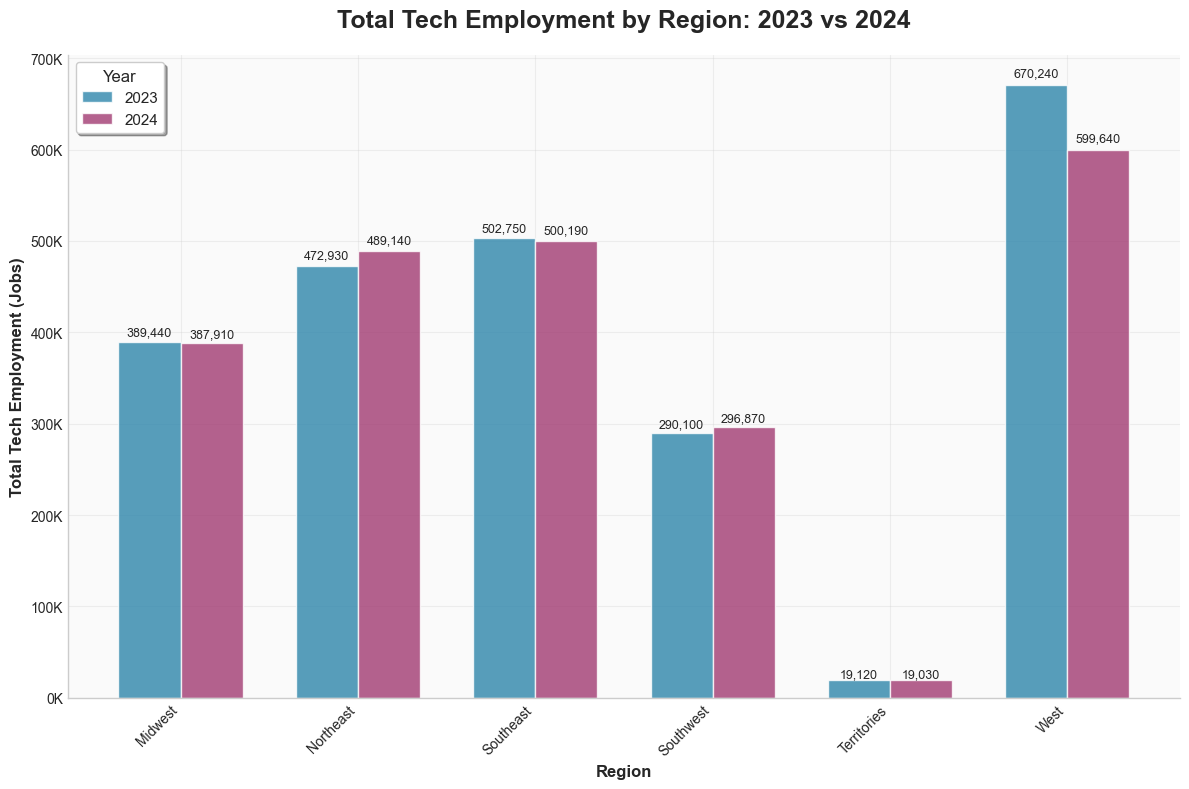


3. Heatmap: AI Adoption Patterns by Region and Time
Query executed: 12 records returned for regional analysis


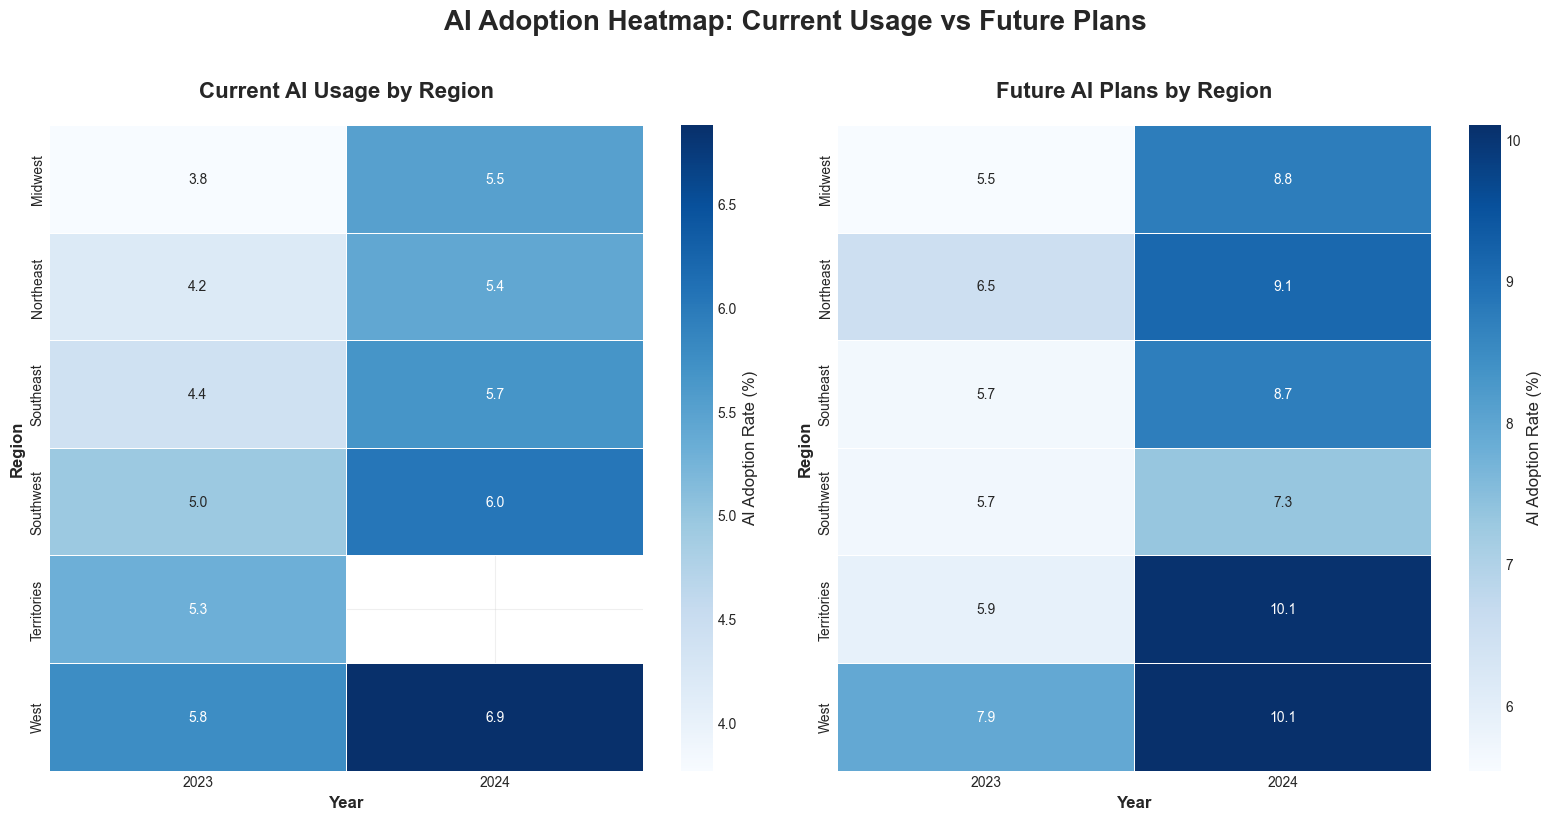

In [42]:
create_all_visualizations()

State Level Visualizations

In [38]:
def create_state_scatter_plot(db_path: str = "data/capstone_analysis.db", region_filter: str = None) -> None:
    """
    Create a scatter plot showing the relationship between tech employment 
    change (2023-2024) and current AI adoption rates by state.
    
    Args:
        db_path (str): Path to the SQLite database
        region_filter (str): Optional region to filter by ('Northeast', 'Southeast', 'Midwest', 'Southwest', 'West')
    """
    colors = setup_plot_theme()
    
    # Get correlation data (state-level) from database
    correlation_data = query_visualization_data(db_path, "correlation")
    
    # Filter by region if specified
    if region_filter:
        correlation_data = correlation_data[correlation_data['region'] == region_filter]
        print(f"Filtering to {region_filter} region only")
    
    # Calculate tech employment change by state using actual employment numbers
    state_changes = []
    for state_code in correlation_data['state_code'].unique():
        # Get employment data for this state
        state_employment = correlation_data[correlation_data['state_code'] == state_code]
        
        # Get 2023 and 2024 employment totals
        employment_2023 = state_employment[state_employment['year'] == 2023]['tech_employment']
        employment_2024 = state_employment[state_employment['year'] == 2024]['tech_employment']
        
        if len(employment_2023) > 0 and len(employment_2024) > 0:
            emp_2023 = employment_2023.iloc[0]
            emp_2024 = employment_2024.iloc[0]
            
            # Calculate percentage change
            if emp_2023 > 0:  # Avoid division by zero
                percent_change = ((emp_2024 - emp_2023) / emp_2023) * 100
            else:
                percent_change = 0
            
            # Get 2024 AI adoption for this state
            state_ai_2024 = state_employment[
                (state_employment['year'] == 2024) &
                (state_employment['current_ai_usage'].notna()) &
                (state_employment['current_ai_usage'] > 0)
            ]
            
            if len(state_ai_2024) > 0:
                ai_usage = state_ai_2024['current_ai_usage'].iloc[0] * 100  # Convert to percentage
                region = state_ai_2024['region'].iloc[0]
                
                state_changes.append({
                    'state_code': state_code,
                    'region': region,
                    'tech_employment_change': percent_change,
                    'ai_adoption_rate': ai_usage,
                    'emp_2023': emp_2023,
                    'emp_2024': emp_2024
                })
    
    change_df = pd.DataFrame(state_changes)
    
    # Debug print to verify calculations
    filter_text = f" in {region_filter}" if region_filter else ""
    print(f"State Employment Change Calculations{filter_text}:")
    print("=" * 60)
    for _, row in change_df.iterrows():
        print(f"{row['state_code']:>3} ({row['region']:>10}): {row['emp_2023']:>8,.0f} → {row['emp_2024']:>8,.0f} "
              f"({row['tech_employment_change']:>+6.2f}%)")
    print()
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Color by region for better interpretation
    region_colors = {
        'Northeast': colors['primary'],
        'Southeast': colors['secondary'], 
        'Midwest': colors['accent'],
        'Southwest': colors['dark'],
        'West': colors['light']
    }
    
    # Plot points colored by region
    for region in change_df['region'].unique():
        region_data = change_df[change_df['region'] == region]
        ax.scatter(region_data['tech_employment_change'], 
                  region_data['ai_adoption_rate'],
                  c=region_colors.get(region, colors['neutral']), 
                  label=region, 
                  alpha=0.7, 
                  s=100,
                  edgecolors='white',
                  linewidth=1)
        
        # Add state code labels
        for _, row in region_data.iterrows():
            ax.annotate(row['state_code'], 
                       (row['tech_employment_change'], row['ai_adoption_rate']),
                       xytext=(2, 2), textcoords='offset points',
                       fontsize=8, fontweight='bold', alpha=0.8)
    
    # Add trend line if we have enough points
    if len(change_df) > 2:
        x = change_df['tech_employment_change']
        y = change_df['ai_adoption_rate']
        
        # Only calculate correlation if we have valid data
        if len(x) > 1 and x.std() > 0 and y.std() > 0:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax.plot(x, p(x), color=colors['neutral'], linestyle='--', alpha=0.8, linewidth=2)
            
            # Add correlation coefficient
            correlation_coef = np.corrcoef(x, y)[0, 1]
            ax.text(0.05, 0.95, f'Correlation: r = {correlation_coef:.3f}', 
                    transform=ax.transAxes, fontsize=12, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Customize the plot
    ax.set_xlabel('Tech Employment Change 2023-2024 (%)', fontweight='bold')
    ax.set_ylabel('Current AI Adoption Rate 2024 (%)', fontweight='bold')
    
    # Update title based on filter
    title = 'State Tech Employment Growth vs AI Adoption (2024)'
    if region_filter:
        title = f'{region_filter} States: Tech Employment Growth vs AI Adoption (2024)'
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add zero lines for reference
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    
    # Add legend (only if multiple regions)
    if not region_filter or len(change_df['region'].unique()) > 1:
        ax.legend(title='Region', title_fontsize=12, fontsize=10, 
                 loc='best', frameon=True, fancybox=True, shadow=True)
    
    # Set grid
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.show()

def create_state_bar_chart(db_path: str = "data/capstone_analysis.db", top_n: int = 15, region_filter: str = None) -> None:
    """
    Create a grouped bar chart comparing total tech jobs by state 
    between 2023 and 2024. Shows top N states by 2024 employment.
    
    Args:
        db_path (str): Path to the SQLite database
        top_n (int): Number of top states to show
        region_filter (str): Optional region to filter by
    """
    colors = setup_plot_theme()
    
    # Get correlation data which has state-level employment data
    correlation_data = query_visualization_data(db_path, "correlation")
    
    # Filter by region if specified
    if region_filter:
        correlation_data = correlation_data[correlation_data['region'] == region_filter]
        print(f"Filtering to {region_filter} region only")
    
    # Create state employment summary
    state_employment = correlation_data.groupby(['state_code', 'year'])['tech_employment'].first().unstack(fill_value=0)
    
    # Sort by 2024 employment and take top N states
    state_employment = state_employment.sort_values(by=2024, ascending=False).head(top_n)
    
    # Create the bar chart
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Set bar positions
    x = np.arange(len(state_employment.index))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, state_employment[2023], width, 
                   label='2023', color=colors['primary'], alpha=0.8,
                   edgecolor='white', linewidth=1)
    bars2 = ax.bar(x + width/2, state_employment[2024], width,
                   label='2024', color=colors['secondary'], alpha=0.8,
                   edgecolor='white', linewidth=1)
    
    # Add value labels on bars (only for larger values to avoid clutter)
    def add_value_labels(bars, values):
        max_val = values.max()
        for bar, value in zip(bars, values):
            height = bar.get_height()
            if height > max_val * 0.1:  # Only label significant bars
                ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                       f'{value:,.0f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    add_value_labels(bars1, state_employment[2023])
    add_value_labels(bars2, state_employment[2024])
    
    # Customize the plot
    ax.set_xlabel('State', fontweight='bold')
    ax.set_ylabel('Total Tech Employment (Jobs)', fontweight='bold')
    
    # Update title based on filter
    title = f'Total Tech Employment by State: 2023 vs 2024 (Top {min(top_n, len(state_employment))} States)'
    if region_filter:
        title = f'{region_filter} States: Tech Employment 2023 vs 2024 (Top {min(top_n, len(state_employment))})'
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(state_employment.index, rotation=45, ha='right')
    
    # Format y-axis to show values in thousands
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    # Add legend
    ax.legend(title='Year', title_fontsize=12, fontsize=11, 
             loc='upper right', frameon=True, fancybox=True, shadow=True)
    
    # Customize grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.show()

def create_state_heatmap_plot(db_path: str = "data/capstone_analysis.db", top_n: int = 20, region_filter: str = None) -> None:
    """
    Create a heatmap showing AI adoption rates (current vs future) by state and year.
    Shows top N states by total tech employment.
    
    Args:
        db_path (str): Path to the SQLite database
        top_n (int): Number of top states to show
        region_filter (str): Optional region to filter by
    """
    colors = setup_plot_theme()
    
    # Get correlation data 
    correlation_data = query_visualization_data(db_path, "correlation")
    
    # Filter by region if specified
    if region_filter:
        correlation_data = correlation_data[correlation_data['region'] == region_filter]
        print(f"Filtering to {region_filter} region only")
    
    # Filter to top N states by 2024 employment to avoid overcrowding
    state_2024_employment = correlation_data[correlation_data['year'] == 2024].nlargest(top_n, 'tech_employment')
    top_states = state_2024_employment['state_code'].tolist()
    filtered_data = correlation_data[correlation_data['state_code'].isin(top_states)]
    
    # Create separate heatmaps for current and future AI adoption
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
    
    # Prepare data for current AI usage
    current_pivot = filtered_data.pivot(index='state_code', columns='year', values='current_ai_usage')
    current_pivot = current_pivot * 100  # Convert to percentage
    
    # Prepare data for future AI plans
    future_pivot = filtered_data.pivot(index='state_code', columns='year', values='future_ai_plans')
    future_pivot = future_pivot * 100  # Convert to percentage
    
    # Create custom colormap
    cmap = sns.color_palette("Blues", as_cmap=True)
    
    # Plot current AI usage heatmap
    sns.heatmap(current_pivot, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                cbar_kws={'label': 'AI Adoption Rate (%)'},
                ax=ax1,
                linewidths=0.5,
                linecolor='white',
                annot_kws={'size': 8})
    
    ax1.set_title('Current AI Usage by State', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Year', fontweight='bold')
    ax1.set_ylabel('State', fontweight='bold')
    ax1.tick_params(axis='y', labelsize=9)
    
    # Plot future AI plans heatmap
    sns.heatmap(future_pivot, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                cbar_kws={'label': 'AI Adoption Rate (%)'},
                ax=ax2,
                linewidths=0.5,
                linecolor='white',
                annot_kws={'size': 8})
    
    ax2.set_title('Future AI Plans by State', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Year', fontweight='bold')
    ax2.set_ylabel('State', fontweight='bold')
    ax2.tick_params(axis='y', labelsize=9)
    
    # Update main title based on filter
    title = f'AI Adoption Heatmap by State: Current Usage vs Future Plans (Top {min(top_n, len(filtered_data["state_code"].unique()))} States)'
    if region_filter:
        title = f'{region_filter} States: AI Adoption Heatmap (Top {min(top_n, len(filtered_data["state_code"].unique()))})'
    
    # Adjust layout
    plt.suptitle(title, fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def create_all_state_visualizations(db_path: str = "data/capstone_analysis.db", 
                                   top_n_bar: int = 15, 
                                   top_n_heatmap: int = 20,
                                   selected_states_line: Optional[list] = None,
                                   region_filter: str = None) -> None:
    """
    Create all visualizations for state-level capstone analysis.
    
    Args:
        db_path (str): Path to the SQLite database
        top_n_bar (int): Number of top states to show in bar chart
        top_n_heatmap (int): Number of top states to show in heatmap
        selected_states_line (list): Specific states for line plot, or None for top 10
        region_filter (str): Optional region to filter by ('Northeast', 'Southeast', 'Midwest', 'Southwest', 'West')
    """
    filter_text = f" - {region_filter} Region" if region_filter else ""
    print(f"Creating State-Level Capstone Visualizations{filter_text}...")
    print("=" * 60)
    
    print(f"\n1. Scatter Plot: State Tech Employment Change vs AI Adoption{filter_text}")
    create_state_scatter_plot(db_path, region_filter)
    
    print(f"\n2. Bar Chart: Total Tech Employment by State (Top {top_n_bar}){filter_text}")
    create_state_bar_chart(db_path, top_n_bar, region_filter)
    
    print(f"\n3. Heatmap: AI Adoption Patterns by State and Time (Top {top_n_heatmap}){filter_text}")
    create_state_heatmap_plot(db_path, top_n_heatmap, region_filter)

# Convenience functions for specific regions
def create_west_state_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """Create all state visualizations for West region only."""
    create_all_state_visualizations(db_path, region_filter="West")

def create_northeast_state_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """Create all state visualizations for Northeast region only."""
    create_all_state_visualizations(db_path, region_filter="Northeast")

def create_southeast_state_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """Create all state visualizations for Southeast region only."""
    create_all_state_visualizations(db_path, region_filter="Southeast")

def create_midwest_state_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """Create all state visualizations for Midwest region only."""
    create_all_state_visualizations(db_path, region_filter="Midwest")

def create_southwest_state_visualizations(db_path: str = "data/capstone_analysis.db") -> None:
    """Create all state visualizations for Southwest region only."""
    create_all_state_visualizations(db_path, region_filter="Southwest")

Creating State-Level Capstone Visualizations...

1. Scatter Plot: State Tech Employment Change vs AI Adoption
Query executed: 107 records returned for correlation analysis
State Employment Change Calculations:
 IA (   Midwest):   15,180 →   14,820 ( -2.37%)
 IL (   Midwest):   82,960 →   79,110 ( -4.64%)
 IN (   Midwest):   22,700 →   21,980 ( -3.17%)
 KS (   Midwest):   18,300 →   19,310 ( +5.52%)
 MI (   Midwest):   57,940 →   56,760 ( -2.04%)
 MN (   Midwest):   46,800 →   49,210 ( +5.15%)
 MO (   Midwest):   31,600 →   29,270 ( -7.37%)
 NE (   Midwest):   13,810 →   14,710 ( +6.52%)
 OH (   Midwest):   62,010 →   63,240 ( +1.98%)
 WI (   Midwest):   32,760 →   33,980 ( +3.72%)
 CT ( Northeast):   23,600 →   21,680 ( -8.14%)
 MA ( Northeast):   79,820 →   77,400 ( -3.03%)
 MD ( Northeast):   44,790 →   48,260 ( +7.75%)
 NJ ( Northeast):   73,310 →   79,740 ( +8.77%)
 NY ( Northeast):  150,740 →  153,090 ( +1.56%)
 PA ( Northeast):   66,120 →   78,060 (+18.06%)
 AL ( Southeast):   23

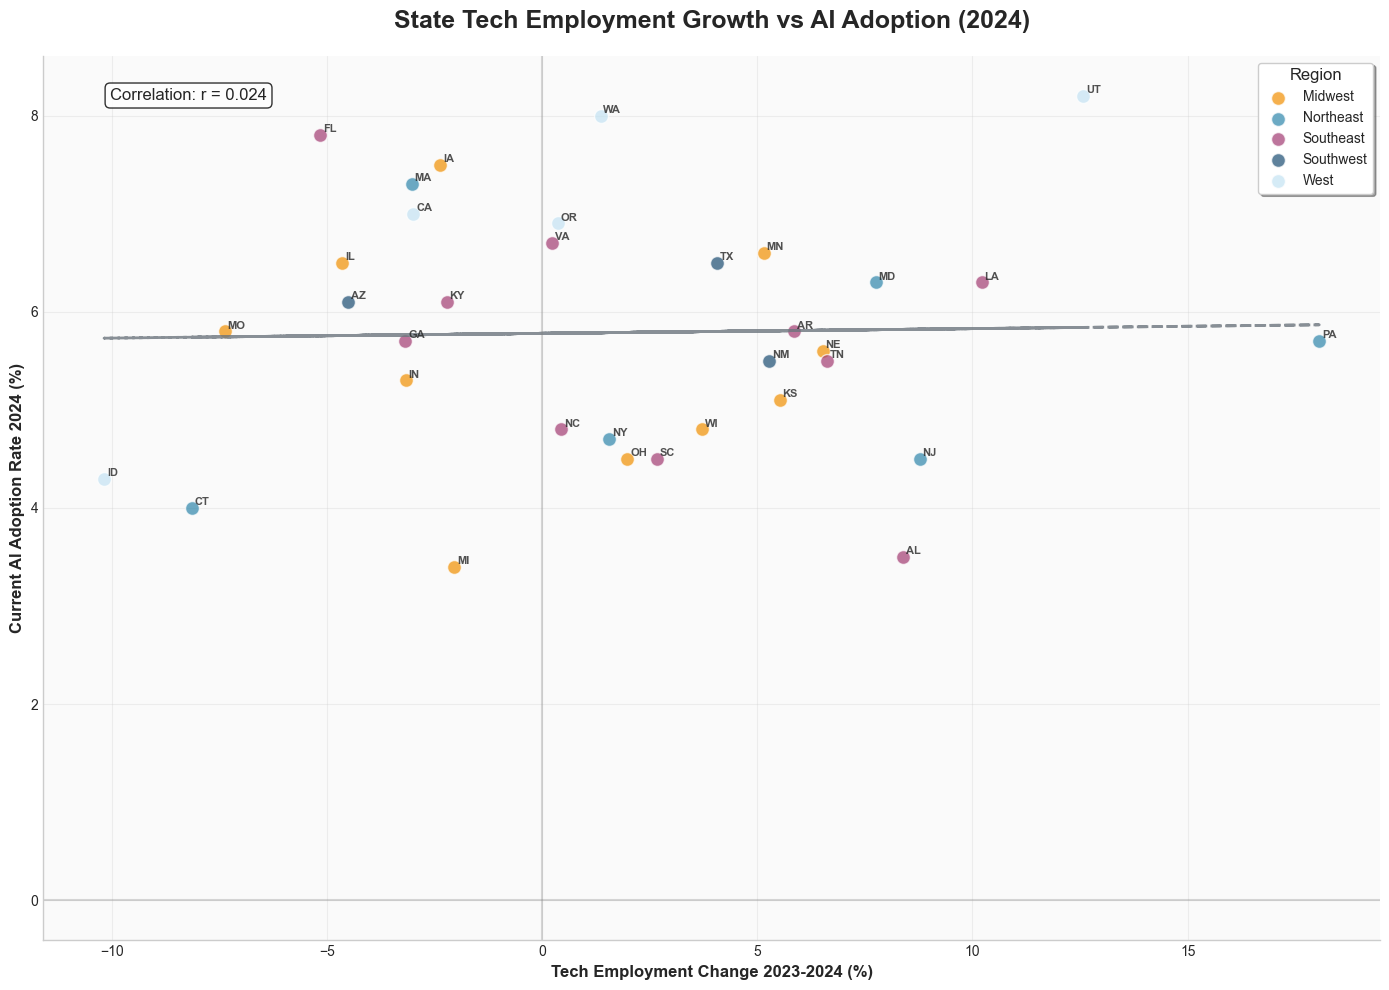


2. Bar Chart: Total Tech Employment by State (Top 15)
Query executed: 107 records returned for correlation analysis


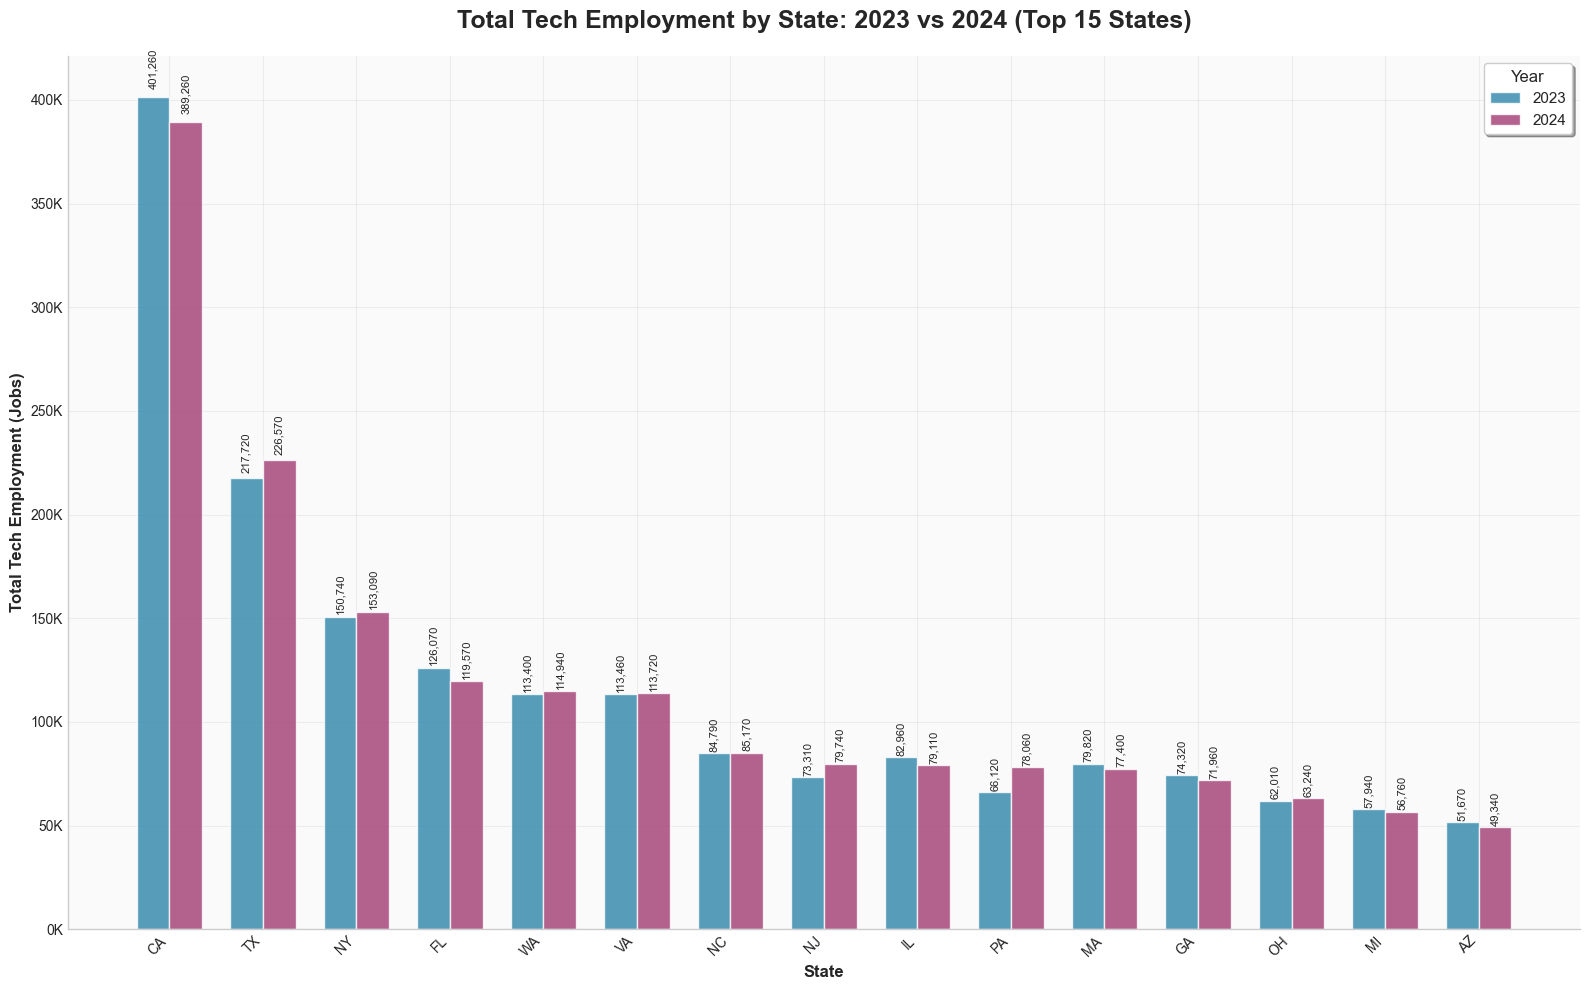


3. Heatmap: AI Adoption Patterns by State and Time (Top 20)
Query executed: 107 records returned for correlation analysis


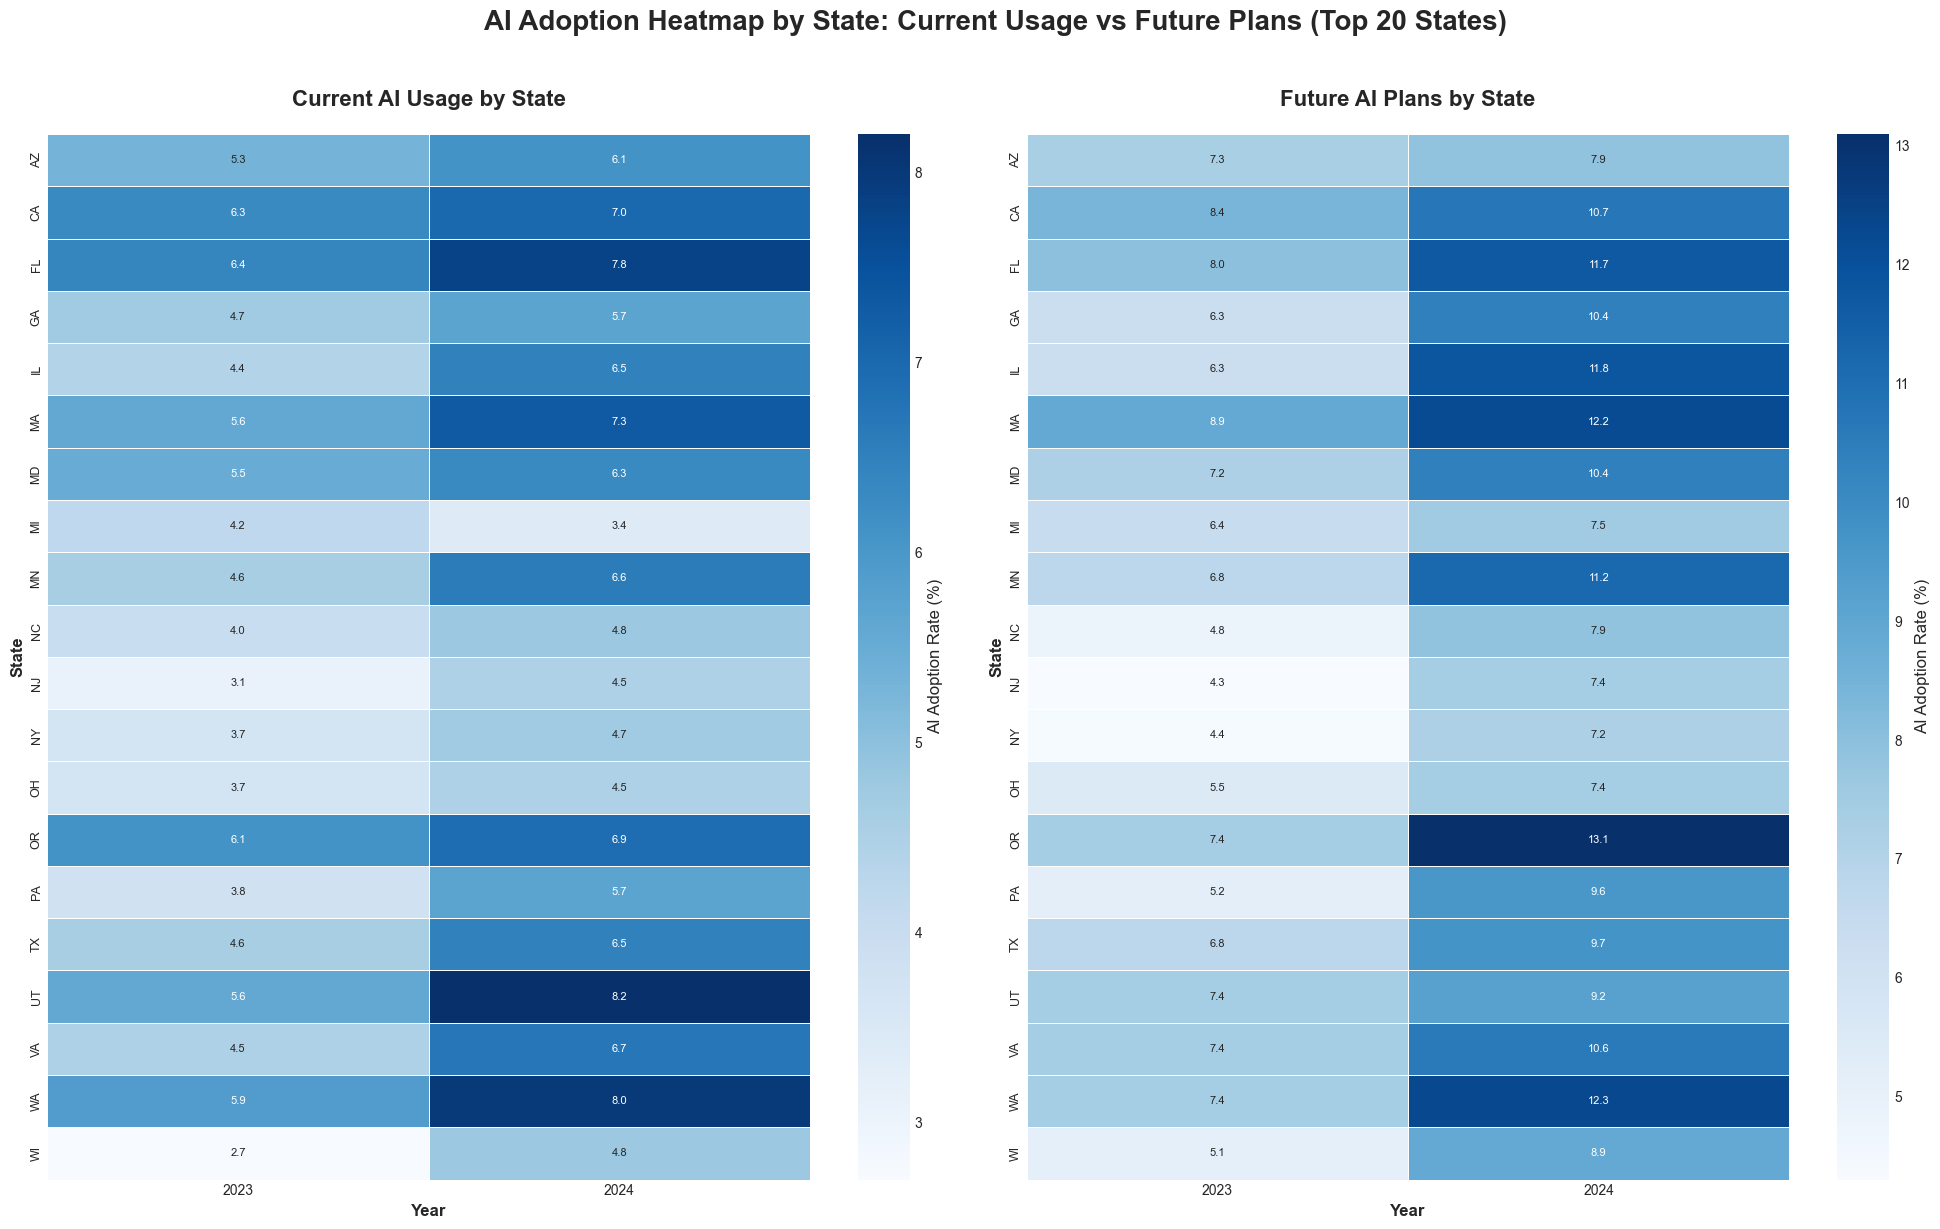

In [39]:
create_all_state_visualizations()